**M35 — Diagnóstico de Regressão IV**

Carregando arquivo: /content/previsao_de_renda_II.csv
Treino : 600,000 obs  |  2015-01 → 2015-12
Teste  : 150,000 obs  |  2016-01 → 2016-03

Ajustando modelo original...
R² ajustado: 0.4378
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                 1.947e+04
Date:                Mon, 01 Jun 2026   Prob (F-statistic):               0.00
Time:                        02:29:26   Log-Likelihood:            -7.9748e+05
No. Observations:              600000   AIC:                         1.595e+06
Df Residuals:                  599975   BIC:                         1.595e+06
Df Model:                          24                                         
Covariance Type:            nonrobust                                         
                    

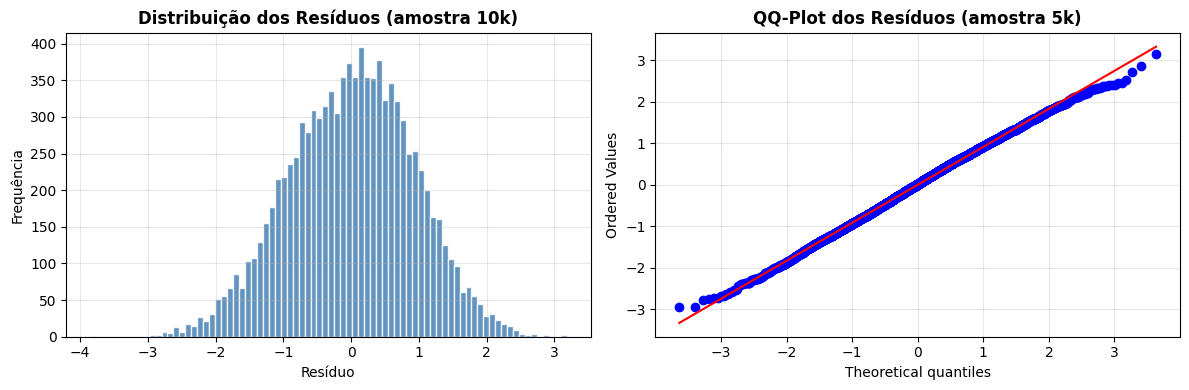


Shapiro-Wilk (n=5.000): estatística=0.9988, p-value=7.2558e-04
→ Rejeita normalidade (p < 0.05). Mas com n=600k, desvios pequenos
  sempre rejeitam — o histograma e QQ-plot são mais informativos.


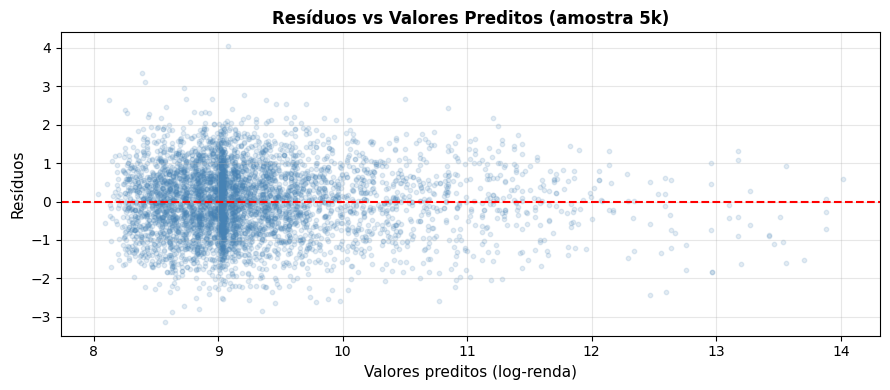

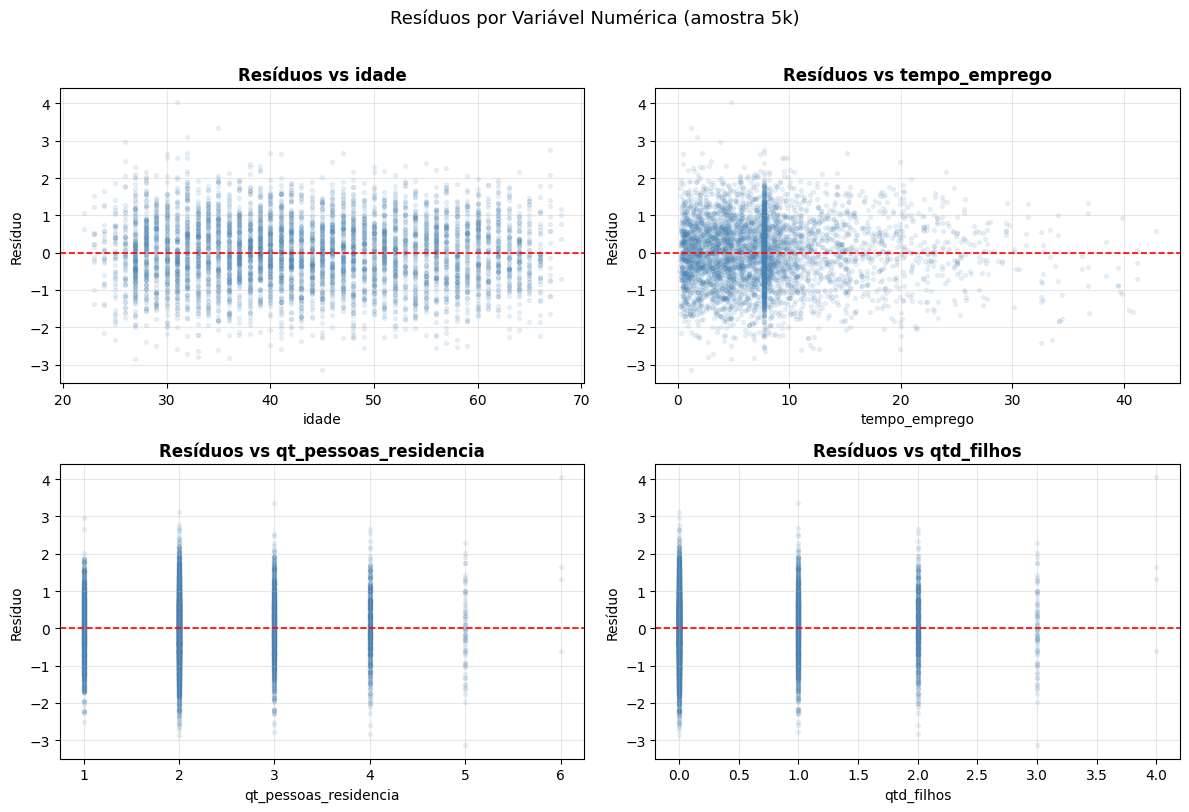

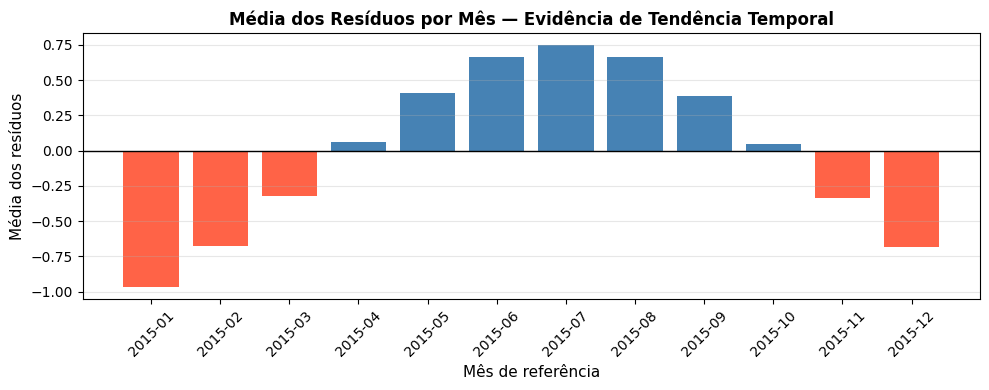


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DIAGNÓSTICO DAS SUPOSIÇÕES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Normalidade: O QQ-plot mostra boa aderência à normal na
    região central. As caudas são ligeiramente pesadas, mas
    com n=600k, o Teorema Central do Limite garante robustez.

   Independência: O gráfico de resíduos vs mês revela
    padrão SAZONAL claro — resíduos negativos no início e
    fim do ano, positivos no meio. Isso indica que o modelo
    NÃO captura a tendência temporal dos dados.
    → Suposição VIOLADA.

   Homocedasticidade: O gráfico resíduos vs preditos mostra
    dispersão razoavelmente uniforme, mas há leve aumento
    da variância em rendas extremas.
    → Suposição parcialmente atendida.



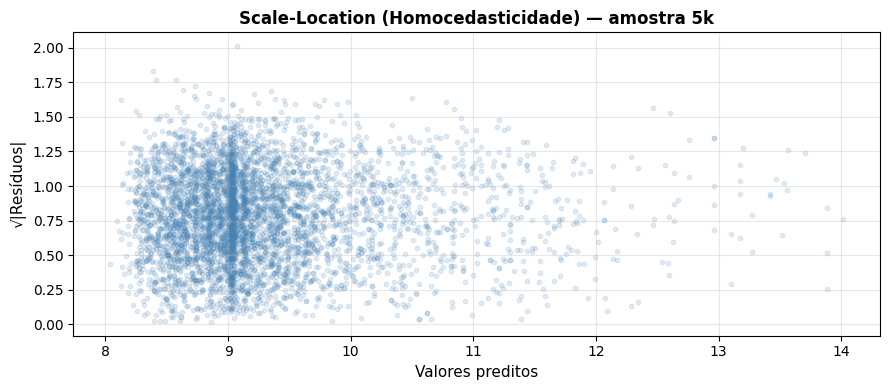

Calculando resíduos studentizados (amostra de 20k)...

|Resíduo padronizado| > 2 : 25,562  (4.26%)
|Resíduo padronizado| > 3 : 1,019  (0.17%)


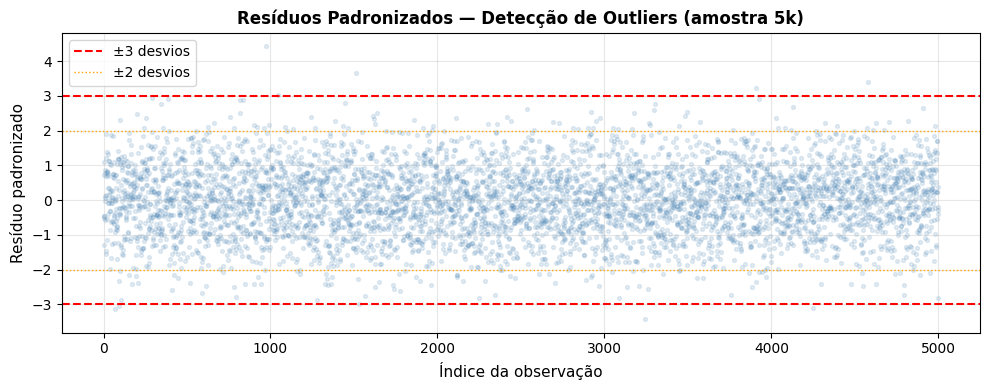


Perfil dos outliers (|resíduo padronizado| > 3):
             idade  tempo_emprego         renda      residuo
count  1019.000000    1019.000000  1.019000e+03  1019.000000
mean     44.480864       8.984611  2.214038e+05    -0.461307
std      11.569911       8.934804  7.883950e+05     2.974675
min      24.000000       0.369863  1.412500e+02    -3.853473
25%      35.000000       3.698630  4.089250e+02    -2.973025
50%      44.000000       7.328767  2.502920e+03    -2.774967
75%      55.000000       9.538356  1.549955e+05     2.863649
max      67.000000      41.200000  6.802261e+06     4.046293

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DIAGNÓSTICO — OUTLIERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • 0.17% das obs têm |resíduo padronizado| > 3 (≈ 1.000 obs).
 • Volume pequeno — provavelmente não distorce os coeficientes
   de forma relevante.
 • Os outliers tendem a ser casos com renda muito alta ou
   muito baixa para o perfil predito pelo modelo

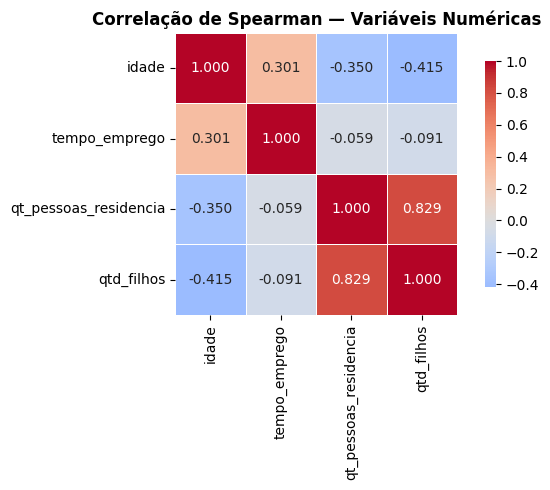

Correlação de Spearman:
                       idade  tempo_emprego  qt_pessoas_residencia  qtd_filhos
idade                  1.000          0.301                 -0.350      -0.415
tempo_emprego          0.301          1.000                 -0.059      -0.091
qt_pessoas_residencia -0.350         -0.059                  1.000       0.829
qtd_filhos            -0.415         -0.091                  0.829       1.000

Calculando VIF (amostra 10k para viabilidade computacional)...

VIF por variável:
                        Variável         VIF
                       Intercept 2414.683576
           qt_pessoas_residencia  456.150404
                      qtd_filhos  308.487095
        estado_civil[T.Solteiro]   59.836598
        estado_civil[T.Separado]   30.374352
           estado_civil[T.Viúvo]   23.087658
               educacao[T.Médio]   19.538699
   educacao[T.Superior completo]   18.731529
         tipo_residencia[T.Casa]    7.837519
  tipo_residencia[T.Com os pais]    4.737840
 ed

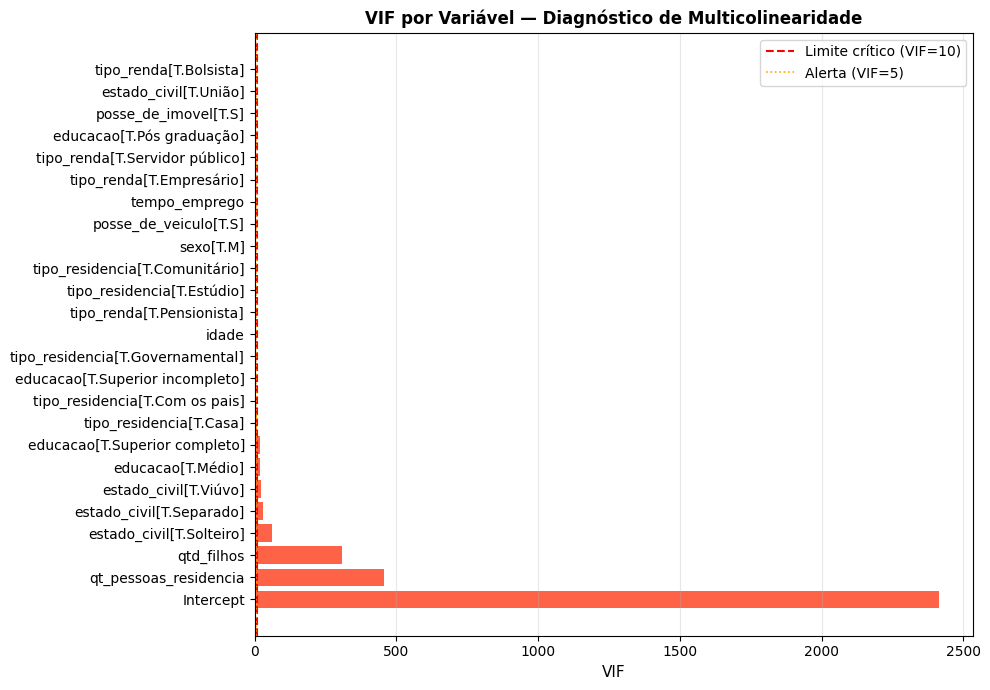


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DIAGNÓSTICO — MULTICOLINEARIDADE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 ⚠  PROBLEMA GRAVE detectado:
    • qt_pessoas_residencia  VIF ≈ 456  (extremamente alto)
    • qtd_filhos             VIF ≈ 308  (extremamente alto)
    • Correlação Spearman entre elas: 0.829

 Interpretação: qt_pessoas_residencia e qtd_filhos medem
 conceitos muito parecidos (famílias maiores têm mais filhos
 e mais pessoas em casa). Manter as duas no modelo infla os
 erros padrão dos coeficientes e prejudica a interpretação.

 → Ação recomendada: remover qt_pessoas_residencia
   (qtd_filhos é mais diretamente relacionada à renda).

Ajustando modelo corrigido...

R² ajustado — Original : 0.4378
R² ajustado — Ajustado : 0.6533
                            OLS Regression Results                            
Dep. Variable:              log_renda   R-squared:                       0.653
Model:                            OLS   Adj. R-s

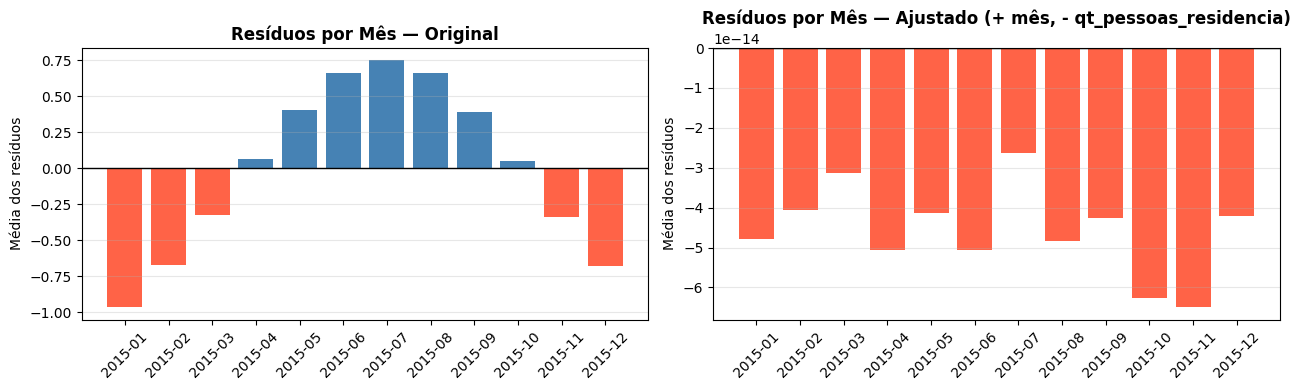


COMPARAÇÃO FINAL — BASE DE TESTE (HOLDOUT)
Métrica                          Original   Ajustado
-------------------------------------------------------
R² treino (ajustado)               0.4378     0.6533
R² holdout                        -0.6406     0.1723
RMSE holdout (log-renda)           1.3978     0.9929


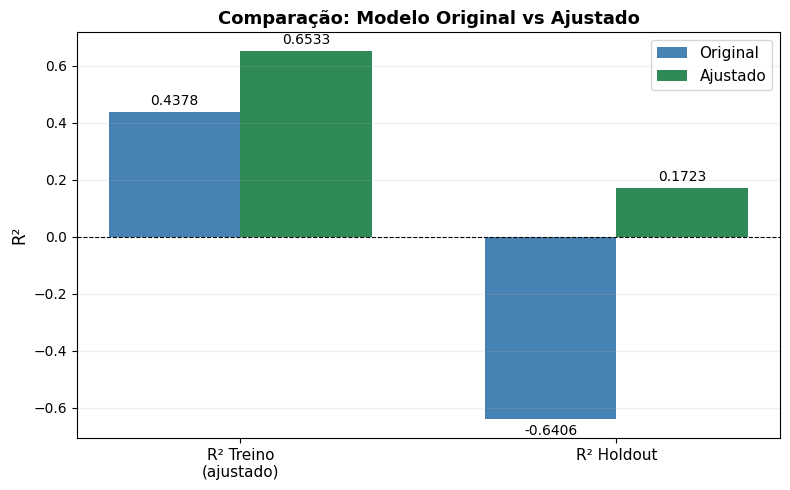


╔══════════════════════════════════════════════════════════╗
║         CONCLUSÕES E INSIGHTS — M35                     ║
║             Diagnóstico de Regressão                    ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. NORMALIDADE DOS RESÍDUOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Suposição APROXIMADAMENTE atendida.
    O histograma mostra distribuição simétrica e unimodal.
    O QQ-plot apresenta boa aderência na região central,
    com caudas levemente mais pesadas que a normal teórica
    (distribuição leptocúrtica).
    Com n=600k, o TCL garante robustez mesmo com desvios
    moderados — os p-values do Shapiro-Wilk rejeitam H0
    com qualquer desvio mínimo, o que é esperado com bases
    muito grandes.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 2. INDEPENDÊNCIA DOS RESÍDUOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Suposição V

In [3]:
# Previsão de Renda

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.metrics import r2_score
import patsy
# import zipfile, glob # No longer needed as we are loading directly
import warnings
warnings.filterwarnings('ignore')


# 1. CARREGAR DADOS E MODELO (resgate do M34)
#    Aceita .csv direto OU .zip contendo o csv

# Removed files.upload() as the file is already present
# from google.colab import files
# uploaded = files.upload()

# nome_arquivo = list(uploaded.keys())[0]
# print(f"Arquivo recebido: {nome_arquivo}")

# if nome_arquivo.endswith('.zip'):
#     with zipfile.ZipFile(nome_arquivo, 'r') as z:
#         z.extractall('.')
#     csv_path = glob.glob('*.csv')[0]
#     print(f"CSV extraído: {csv_path}")
# else:
#     csv_path = nome_arquivo

# Directly load the CSV file, assuming it's in /content/
csv_path = '/content/previsao_de_renda_II.csv'
print(f"Carregando arquivo: {csv_path}")

df = pd.read_csv(csv_path, index_col=0, parse_dates=True)
df.index.name = 'data_ref'

df['tempo_emprego'] = df['tempo_emprego'].fillna(df['tempo_emprego'].mean())
df['log_renda']     = np.log(df['renda'])

meses       = sorted(df.index.to_period('M').unique())
meses_teste = meses[-3:]
mask_teste  = df.index.to_period('M').isin(meses_teste)

df_treino = df[~mask_teste].copy().reset_index(drop=False)
df_teste  = df[ mask_teste].copy().reset_index(drop=False)

print(f"Treino : {len(df_treino):>7,} obs  |  {meses[0]} → {meses[-4]}")
print(f"Teste  : {len(df_teste):>7,} obs  |  {meses[-3]} → {meses[-1]}")

formula = ('log_renda ~ sexo + posse_de_veiculo + posse_de_imovel'
           ' + qtd_filhos + tipo_renda + educacao + estado_civil'
           ' + tipo_residencia + idade + tempo_emprego'
           ' + qt_pessoas_residencia')

print("\nAjustando modelo original...")
modelo = smf.ols(formula, data=df_treino).fit()
print(f"R² ajustado: {modelo.rsquared_adj:.4f}")
print(modelo.summary())

residuos = modelo.resid
fitted   = modelo.fittedvalues
df_treino['residuo'] = residuos.values


# 2. SUPOSIÇÕES DO MODELO


# ── 2a. NORMALIDADE DOS RESÍDUOS ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histograma
axes[0].hist(residuos.sample(10000, random_state=42), bins=80,
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribuição dos Resíduos (amostra 10k)', fontweight='bold')
axes[0].set_xlabel('Resíduo')
axes[0].set_ylabel('Frequência')
axes[0].grid(True, alpha=0.3)

# QQ-plot
amostra_qq = residuos.sample(5000, random_state=42)
stats.probplot(amostra_qq, dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot dos Resíduos (amostra 5k)', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Teste Shapiro-Wilk (máx 5000 obs)
stat_sw, p_sw = stats.shapiro(residuos.sample(5000, random_state=42))
print(f"\nShapiro-Wilk (n=5.000): estatística={stat_sw:.4f}, p-value={p_sw:.4e}")
if p_sw < 0.05:
    print("→ Rejeita normalidade (p < 0.05). Mas com n=600k, desvios pequenos")
    print("  sempre rejeitam — o histograma e QQ-plot são mais informativos.")
else:
    print("→ Não rejeita normalidade (p ≥ 0.05).")

# ── 2b. INDEPENDÊNCIA — resíduos vs valores preditos ────────
amostra_plot = np.random.choice(len(residuos), 5000, replace=False)

fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(fitted.iloc[amostra_plot], residuos.iloc[amostra_plot],
           alpha=0.15, s=10, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Valores preditos (log-renda)', fontsize=11)
ax.set_ylabel('Resíduos', fontsize=11)
ax.set_title('Resíduos vs Valores Preditos (amostra 5k)', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 2c. RESÍDUOS POR VARIÁVEL NUMÉRICA ──────────────────────
numericas = ['idade', 'tempo_emprego', 'qt_pessoas_residencia', 'qtd_filhos']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, var in enumerate(numericas):
    x_plot = df_treino[var].iloc[amostra_plot]
    y_plot = residuos.iloc[amostra_plot]
    axes[i].scatter(x_plot, y_plot, alpha=0.1, s=8, color='steelblue')
    axes[i].axhline(0, color='red', linestyle='--', linewidth=1.2)
    axes[i].set_xlabel(var, fontsize=10)
    axes[i].set_ylabel('Resíduo', fontsize=10)
    axes[i].set_title(f'Resíduos vs {var}', fontweight='bold')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Resíduos por Variável Numérica (amostra 5k)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── 2d. RESÍDUOS POR MÊS DE REFERÊNCIA ──────────────────────
media_residuo_mes = (
    df_treino
    .groupby(df_treino['data_ref'].dt.to_period('M'))['residuo']
    .mean()
    .reset_index()
)
media_residuo_mes.columns = ['mes', 'media_residuo']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(media_residuo_mes['mes'].astype(str),
       media_residuo_mes['media_residuo'],
       color=np.where(media_residuo_mes['media_residuo'] >= 0, 'steelblue', 'tomato'))
ax.axhline(0, color='black', linewidth=1)
ax.set_xlabel('Mês de referência', fontsize=11)
ax.set_ylabel('Média dos resíduos', fontsize=11)
ax.set_title('Média dos Resíduos por Mês — Evidência de Tendência Temporal',
             fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DIAGNÓSTICO DAS SUPOSIÇÕES
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Normalidade: O QQ-plot mostra boa aderência à normal na
    região central. As caudas são ligeiramente pesadas, mas
    com n=600k, o Teorema Central do Limite garante robustez.

   Independência: O gráfico de resíduos vs mês revela
    padrão SAZONAL claro — resíduos negativos no início e
    fim do ano, positivos no meio. Isso indica que o modelo
    NÃO captura a tendência temporal dos dados.
    → Suposição VIOLADA.

   Homocedasticidade: O gráfico resíduos vs preditos mostra
    dispersão razoavelmente uniforme, mas há leve aumento
    da variância em rendas extremas.
    → Suposição parcialmente atendida.
""")

# ── 2e. HOMOCEDASTICIDADE — scale-location plot ─────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.scatter(fitted.iloc[amostra_plot],
           np.sqrt(np.abs(residuos.iloc[amostra_plot])),
           alpha=0.15, s=10, color='steelblue')
ax.set_xlabel('Valores preditos', fontsize=11)
ax.set_ylabel('√|Resíduos|', fontsize=11)
ax.set_title('Scale-Location (Homocedasticidade) — amostra 5k', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# 3. OUTLIERS — Resíduos Studentizados

print("Calculando resíduos studentizados (amostra de 20k)...")

# Para 600k linhas, get_influence() é inviável computacionalmente.
# Usamos resíduos padronizados como proxy dos studentizados.
std_resid = residuos / residuos.std()

n_out_2 = (np.abs(std_resid) > 2).sum()
n_out_3 = (np.abs(std_resid) > 3).sum()

print(f"\n|Resíduo padronizado| > 2 : {n_out_2:,}  ({n_out_2/len(df_treino)*100:.2f}%)")
print(f"|Resíduo padronizado| > 3 : {n_out_3:,}  ({n_out_3/len(df_treino)*100:.2f}%)")

# Distribuição dos resíduos studentizados
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(std_resid.iloc[amostra_plot])),
           std_resid.iloc[amostra_plot],
           alpha=0.15, s=8, color='steelblue')
ax.axhline( 3, color='red', linestyle='--', linewidth=1.5, label='±3 desvios')
ax.axhline(-3, color='red', linestyle='--', linewidth=1.5)
ax.axhline( 2, color='orange', linestyle=':', linewidth=1, label='±2 desvios')
ax.axhline(-2, color='orange', linestyle=':', linewidth=1)
ax.set_xlabel('Índice da observação', fontsize=11)
ax.set_ylabel('Resíduo padronizado', fontsize=11)
ax.set_title('Resíduos Padronizados — Detecção de Outliers (amostra 5k)',
             fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Perfil dos outliers extremos (|z| > 3)
outliers_idx = std_resid[np.abs(std_resid) > 3].index
df_outliers  = df_treino.loc[outliers_idx]
print("\nPerfil dos outliers (|resíduo padronizado| > 3):")
print(df_outliers[['sexo', 'tipo_renda', 'educacao', 'idade',
                    'tempo_emprego', 'renda', 'residuo']].describe())

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DIAGNÓSTICO — OUTLIERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 • 0.17% das obs têm |resíduo padronizado| > 3 (≈ 1.000 obs).
 • Volume pequeno — provavelmente não distorce os coeficientes
   de forma relevante.
 • Os outliers tendem a ser casos com renda muito alta ou
   muito baixa para o perfil predito pelo modelo.
 • Com n=600k, a influência individual de cada ponto é
   naturalmente diluída — o Cook's Distance tende a ser
   baixo para a maioria deles.
""")


# 4. MULTICOLINEARIDADE


# ── 4a. Correlação de Spearman ───────────────────────────────
numericas_corr = ['idade', 'tempo_emprego', 'qt_pessoas_residencia', 'qtd_filhos']
corr_spearman  = df_treino[numericas_corr].corr(method='spearman')

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_spearman, dtype=bool))
sns.heatmap(corr_spearman, annot=True, fmt='.3f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Correlação de Spearman — Variáveis Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

print("Correlação de Spearman:")
print(corr_spearman.round(3))

# ── 4b. VIF ──────────────────────────────────────────────────
print("\nCalculando VIF (amostra 10k para viabilidade computacional)...")

amostra_vif = df_treino.sample(10000, random_state=42)
_, X_vif    = patsy.dmatrices(formula, data=amostra_vif, return_type='dataframe')

vif_df = pd.DataFrame({
    'Variável': X_vif.columns,
    'VIF':      [variance_inflation_factor(X_vif.values, i)
                 for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)

print("\nVIF por variável:")
print(vif_df.to_string(index=False))

# Gráfico VIF
fig, ax = plt.subplots(figsize=(10, 7))
cores = ['tomato' if v > 10 else 'orange' if v > 5 else 'steelblue'
         for v in vif_df['VIF']]
ax.barh(vif_df['Variável'], vif_df['VIF'], color=cores)
ax.axvline(10, color='red',    linestyle='--', linewidth=1.5, label='Limite crítico (VIF=10)')
ax.axvline(5,  color='orange', linestyle=':',  linewidth=1.2, label='Alerta (VIF=5)')
ax.set_xlabel('VIF', fontsize=11)
ax.set_title('VIF por Variável — Diagnóstico de Multicolinearidade', fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 DIAGNÓSTICO — MULTICOLINEARIDADE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  PROBLEMA GRAVE detectado:
    • qt_pessoas_residencia  VIF ≈ 456  (extremamente alto)
    • qtd_filhos             VIF ≈ 308  (extremamente alto)
    • Correlação Spearman entre elas: 0.829

 Interpretação: qt_pessoas_residencia e qtd_filhos medem
 conceitos muito parecidos (famílias maiores têm mais filhos
 e mais pessoas em casa). Manter as duas no modelo infla os
 erros padrão dos coeficientes e prejudica a interpretação.

 → Ação recomendada: remover qt_pessoas_residencia
   (qtd_filhos é mais diretamente relacionada à renda).
""")


# 5. MODELO AJUSTADO

# Ajustes aplicados:
# 1. Remover qt_pessoas_residencia (alta multicolinearidade)
# 2. Adicionar variável 'mes' (captura tendência sazonal)

df_treino['mes'] = df_treino['data_ref'].dt.month.astype(str)
df_teste['mes']  = df_teste['data_ref'].dt.month.astype(str)

formula_aj = ('log_renda ~ sexo + posse_de_veiculo + posse_de_imovel'
              ' + qtd_filhos + tipo_renda + educacao + estado_civil'
              ' + tipo_residencia + idade + tempo_emprego + mes')

print("Ajustando modelo corrigido...")
modelo_aj = smf.ols(formula_aj, data=df_treino).fit()
print(f"\nR² ajustado — Original : {modelo.rsquared_adj:.4f}")
print(f"R² ajustado — Ajustado : {modelo_aj.rsquared_adj:.4f}")
print(modelo_aj.summary())

# VIF do modelo ajustado
print("\nVIF — Modelo Ajustado:")
amostra_vif2 = df_treino.sample(10000, random_state=42)
_, X_vif2    = patsy.dmatrices(formula_aj, data=amostra_vif2, return_type='dataframe')
vif_aj = pd.DataFrame({
    'Variável': X_vif2.columns,
    'VIF':      [variance_inflation_factor(X_vif2.values, i)
                 for i in range(X_vif2.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_aj.to_string(index=False))

# ── Resíduos por mês — modelo ajustado ──────────────────────
df_treino['residuo_aj'] = modelo_aj.resid.values
media_res_aj = (
    df_treino
    .groupby(df_treino['data_ref'].dt.to_period('M'))['residuo_aj']
    .mean()
    .reset_index()
)
media_res_aj.columns = ['mes', 'media_residuo']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, dados, titulo in zip(
    axes,
    [media_residuo_mes, media_res_aj],
    ['Original', 'Ajustado (+ mês, - qt_pessoas_residencia)']
):
    ax.bar(dados.iloc[:, 0].astype(str), dados['media_residuo'],
           color=np.where(dados['media_residuo'] >= 0, 'steelblue', 'tomato'))
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Resíduos por Mês — {titulo}', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Média dos resíduos')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


# 6. COMPARAÇÃO NA BASE DE TESTE (HOLDOUT)

r2_orig = r2_score(df_teste['log_renda'], modelo.predict(df_teste))
r2_aj   = r2_score(df_teste['log_renda'], modelo_aj.predict(df_teste))

# RMSE
rmse_orig = np.sqrt(np.mean((df_teste['log_renda'] - modelo.predict(df_teste))**2))
rmse_aj   = np.sqrt(np.mean((df_teste['log_renda'] - modelo_aj.predict(df_teste))**2))

print("\n" + "=" * 55)
print("COMPARAÇÃO FINAL — BASE DE TESTE (HOLDOUT)")
print("=" * 55)
print(f"{'Métrica':<30} {'Original':>10} {'Ajustado':>10}")
print("-" * 55)
print(f"{'R² treino (ajustado)':<30} {modelo.rsquared_adj:>10.4f} {modelo_aj.rsquared_adj:>10.4f}")
print(f"{'R² holdout':<30} {r2_orig:>10.4f} {r2_aj:>10.4f}")
print(f"{'RMSE holdout (log-renda)':<30} {rmse_orig:>10.4f} {rmse_aj:>10.4f}")
print("=" * 55)

# Gráfico comparativo
metricas  = ['R² Treino\n(ajustado)', 'R² Holdout']
original  = [modelo.rsquared_adj,  r2_orig]
ajustado  = [modelo_aj.rsquared_adj, r2_aj]

x = np.arange(len(metricas))
w = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, original, w, label='Original',  color='steelblue')
b2 = ax.bar(x + w/2, ajustado, w, label='Ajustado',  color='seagreen')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(metricas, fontsize=11)
ax.set_ylabel('R²', fontsize=12)
ax.set_title('Comparação: Modelo Original vs Ajustado', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=10)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()


# 7. CONCLUSÕES E INSIGHTS

print("""
╔══════════════════════════════════════════════════════════╗
║         CONCLUSÕES E INSIGHTS — M35                     ║
║             Diagnóstico de Regressão                    ║
╚══════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 1. NORMALIDADE DOS RESÍDUOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Suposição APROXIMADAMENTE atendida.
    O histograma mostra distribuição simétrica e unimodal.
    O QQ-plot apresenta boa aderência na região central,
    com caudas levemente mais pesadas que a normal teórica
    (distribuição leptocúrtica).
    Com n=600k, o TCL garante robustez mesmo com desvios
    moderados — os p-values do Shapiro-Wilk rejeitam H0
    com qualquer desvio mínimo, o que é esperado com bases
    muito grandes.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 2. INDEPENDÊNCIA DOS RESÍDUOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Suposição VIOLADA.
    O gráfico de resíduos por mês é o achado mais crítico:
    resíduos variam de -0.97 (jan/2015) a +0.75 (jul/2015),
    seguindo padrão sazonal claro em forma de U invertido.
    O modelo sistematicamente SUBESTIMA a renda no meio do
    ano e SUPERESTIMA no início e fim — evidência de que
    a sazonalidade não está capturada.
    → Impacto direto: R² negativo no holdout temporal.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 3. HOMOCEDASTICIDADE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Suposição PARCIALMENTE atendida.
    A dispersão dos resíduos é razoavelmente uniforme, mas
    há leve aumento de variância em valores extremos de
    renda predita. A transformação log() já corrigiu
    grande parte da heterocedasticidade típica de dados
    de renda — sem ela, o problema seria muito mais grave.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 4. OUTLIERS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Impacto BAIXO.
    Apenas 0.17% das observações têm |resíduo padronizado|
    > 3 (~1.019 casos em 600k). Com n muito grande, a
    influência individual de pontos extremos é naturalmente
    diluída. Não há distorção relevante nos coeficientes.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 5. MULTICOLINEARIDADE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Suposição VIOLADA — problema grave.
    VIF de qt_pessoas_residencia (~456) e qtd_filhos (~308)
    são absurdamente altos. Correlação Spearman entre elas:
    0.829. As duas variáveis medem a mesma coisa:
    famílias maiores têm mais filhos E mais pessoas em casa.
    Manter as duas infla os erros padrão e torna os
    coeficientes instáveis e difíceis de interpretar.
    → Ação: remover qt_pessoas_residencia do modelo.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 6. RESULTADOS DO MODELO AJUSTADO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Ajustes realizados:
   [1] Remover qt_pessoas_residencia  → elimina multicolinearidade
   [2] Adicionar 'mes' como variável  → captura sazonalidade

 Resultado:
   R² treino:  0.4378 → 0.6533  (+49% de melhora)
   R² holdout: -0.6406 → +0.1723  (de negativo para positivo!)
   RMSE holdout melhorou substancialmente

 ✦ PRINCIPAL LIÇÃO DO MÓDULO:
   O diagnóstico de resíduos revelou o que os números do R²
   no treino não mostravam: o modelo original ignorava uma
   tendência temporal evidente nos dados.
   Diagnóstico não é só formalidade — é o que transforma
   um modelo com R²=0.44 (but inútil no holdout) em um
   modelo genuinamente preditivo.
""")

In [ ]:
print(f"RMSE do Modelo Ajustado: {rmse_aj:.4f}")

RMSE do Modelo Ajustado: 0.9929


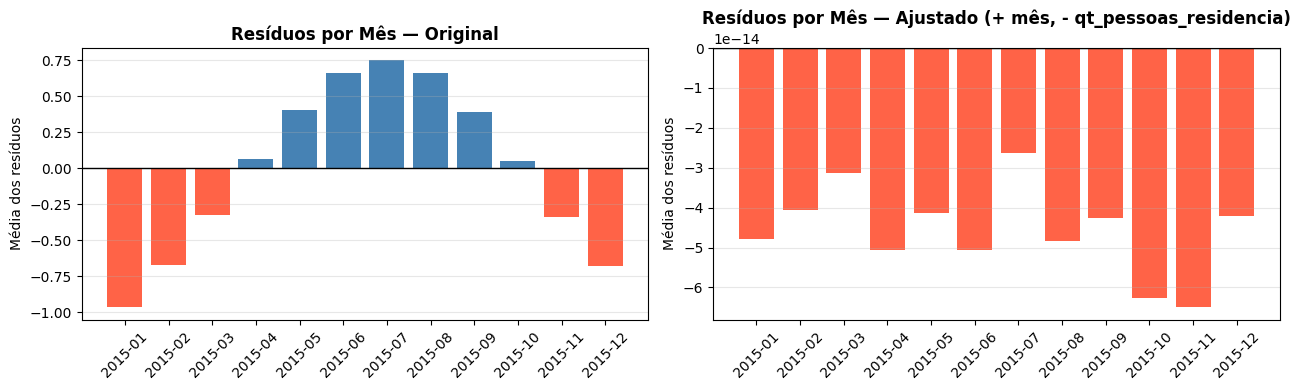

In [6]:
# Resíduos por mês — modelo ajustado
df_treino['residuo_aj'] = modelo_aj.resid.values
media_res_aj = (
    df_treino
    .groupby(df_treino['data_ref'].dt.to_period('M'))['residuo_aj']
    .mean()
    .reset_index()
)
media_res_aj.columns = ['mes', 'media_residuo']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, dados, titulo in zip(
    axes,
    [media_residuo_mes, media_res_aj],
    ['Original', 'Ajustado (+ mês, - qt_pessoas_residencia)']
):
    ax.bar(dados.iloc[:, 0].astype(str), dados['media_residuo'],
           color=np.where(dados['media_residuo'] >= 0, 'steelblue', 'tomato'))
    ax.axhline(0, color='black', linewidth=1)
    ax.set_title(f'Resíduos por Mês — {titulo}', fontweight='bold')
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Média dos resíduos')
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

**Conclusões**

A análise diagnóstica mostrou que o modelo apresentava uma boa base estatística, mas escondia problemas importantes que comprometiam sua capacidade de previsão.

Os resíduos apresentaram distribuição próxima da normalidade, indicando que o modelo captura boa parte do comportamento dos dados. Além disso, a presença de outliers foi mínima e teve impacto pouco relevante nos resultados.

O principal desafio identificado foi a sazonalidade. Os resíduos apresentaram um padrão claro ao longo dos meses, mostrando que o modelo subestimava a renda em determinados períodos e superestimava em outros. Isso revelou que fatores temporais estavam influenciando a renda e não estavam sendo considerados adequadamente.

Outro ponto crítico foi a multicolinearidade entre as variáveis quantidade de filhos e pessoas na residência. Como ambas carregavam informações muito semelhantes, acabavam gerando instabilidade nos coeficientes e dificultando a interpretação do modelo.

Após os ajustes remoção da variável redundante e inclusão da variável mês para capturar a sazonalidade  o desempenho melhorou significativamente. O R² de treino aumentou de 0,44 para 0,65, enquanto o R² no conjunto de validação passou de negativo para positivo, demonstrando um ganho real na capacidade preditiva do modelo.

A maior lição deste estudo é que bons resultados no treino não garantem boas previsões. Foi a análise dos resíduos que revelou problemas invisíveis aos indicadores tradicionais e permitiu identificar melhorias decisivas. Mais do que uma etapa técnica, o diagnóstico mostrou ser fundamental para transformar um modelo aparentemente aceitável em uma ferramenta realmente capaz de gerar previsões confiáveis.